In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import mlflow
import traceback
from dotenv import load_dotenv
from mlflow.tracking import MlflowClient
import pandas as pd

f:\DiskE\SKRIPSI-CODE\skripsi-code\ai\.venv\Lib\site-packages\mlflow\utils\autologging_utils\versioning.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


### Try to load using MLflow API

This doesn't work, scroll below to the next chapter

In [2]:
# load_dotenv()

# tracking_uri = os.getenv("MLFLOW_TRACKING_URI")
# mlflow.set_tracking_uri(tracking_uri)  # type: ignore
# client: MlflowClient = MlflowClient(tracking_uri=tracking_uri)

# # RUN_ID = "906cef2b2f4f465eb47f298a50065e54"
# RUN_ID = "15fc890603d149e4918a1c6cfbf9aa48"

# METRICS_TO_PLOT: list[str] = [
#     # "avg_train_loss",
#     "val_loss_avg",
#     # "val_macro_pr_auc",
#     # "val_macro_roc_auc",
# ]

# run = client.get_run(RUN_ID)
# print(list(run.data.metrics.keys()))
# # print(run)


# def get_and_clean_metric(client: MlflowClient, run_id, metric_key):
#     """Fetches metric history from MLflow and removes NaN or None values."""
#     try:
#         history = client.get_metric_history(run_id, metric_key)
#         print("history", history)

#         steps = []
#         values = []

#         for m in history:
#             if m.value is not None and not np.isnan(m.value):
#                 steps.append(m.step)
#                 values.append(m.value)

#         return steps, values

#     except Exception as e:
#         traceback.print_exc()
#         print(f"Could not retrieve '{metric_key}': {e}")
#         return [], []


# num_metrics = len(METRICS_TO_PLOT)
# fig, axes = plt.subplots(nrows=num_metrics, ncols=1, figsize=(10, 4 * num_metrics))

# # Check axes is iterable even if there's only one metric
# if num_metrics == 1:
#     axes = [axes]

# for ax, metric_key in zip(axes, METRICS_TO_PLOT):
#     steps, values = get_and_clean_metric(client, RUN_ID, metric_key)

#     if len(steps) == 0:
#         ax.text(
#             0.5,
#             0.5,
#             f"No valid data for {metric_key}",
#             ha="center",
#             va="center",
#             transform=ax.transAxes,
#         )
#         ax.set_title(metric_key)
#         continue

#     ax.plot(steps, values, marker="o", linestyle="-", color="b", label=metric_key)
#     ax.set_title(f"{metric_key} over Epochs")
#     ax.set_xlabel("Epoch / Step")
#     ax.set_ylabel("Value")
#     ax.grid(True, linestyle="--", alpha=1)
#     ax.legend()

# plt.tight_layout()
# plt.show()

# This works

In [3]:
df = pd.read_csv("./mlflow_pgdump/906cef_history.csv")
df.head()

,key,value,timestamp,run_uuid,step,is_nan
0,val_pr_auc_mood/theme---slow,0.045309,1780302780671,906cef2b2f4f465eb47f298a50065e54,0,f
1,val_roc_auc_mood/theme---slow,0.742095,1780302780671,906cef2b2f4f465eb47f298a50065e54,0,f
2,val_roc_auc_mood/theme---movie,0.767623,1780302780671,906cef2b2f4f465eb47f298a50065e54,0,f
3,val_pr_auc_mood/theme---movie,0.108775,1780302780671,906cef2b2f4f465eb47f298a50065e54,0,f
4,val_roc_auc_mood/theme---motivational,0.865343,1780302780671,906cef2b2f4f465eb47f298a50065e54,0,f


In [4]:
def plot_db_metrics(df: pd.DataFrame, metrics_to_plot: list[str]):
    """
    Takes a raw MLflow PostgreSQL metrics dump and a list of metric keys,
    filters out the NaNs, and plots them in stacked subplots.
    """
    num_metrics = len(metrics_to_plot)

    if num_metrics == 0:
        print("No metrics provided to plot.")
        return

    _, axes = plt.subplots(nrows=num_metrics, ncols=1, figsize=(10, 4 * num_metrics))

    if num_metrics == 1:
        axes = [axes]

    for ax, metric_key in zip(axes, metrics_to_plot):
        if "pr" in metric_key:
            df_clean = df[
                (df["key"] == metric_key)
                & (df["is_nan"].isin(["f", "F", False, 0]))
                & (df["value"] > 0.0)
            ].copy()
        elif "roc" in metric_key:
            df_clean = df[
                (df["key"] == metric_key)
                & (df["is_nan"].isin(["f", "F", False, 0]))
                & (df["value"] > 0.5)
            ].copy()
        else:
            df_clean = df[
                (df["key"] == metric_key)
                & (df["is_nan"].isin(["f", "F", False, 0]))
                & (df["value"].notna())
            ].copy()

        df_clean = df_clean.sort_values(by="step")

        # Handle edge case where the metric exists but all values were NaN
        if df_clean.empty:
            ax.text(
                0.5,
                0.5,
                f"No valid data found for '{metric_key}'",
                ha="center",
                va="center",
                transform=ax.transAxes,
            )
            ax.set_title(metric_key)
            continue

        ax.plot(
            df_clean["step"].apply(lambda x: x + 1),
            df_clean["value"],
            marker="o",
            linestyle="-",
            color="b",
            label=metric_key,
        )

        ax.set_title(f"{metric_key} over epochs")
        ax.set_xlabel("epoch")
        ax.set_xticks(np.arange(1, stop=len(df_clean["step"]) + 1))
        ax.set_ylabel("value")
        ax.grid(True, linestyle="--", alpha=0.7)
        ax.legend()

    plt.tight_layout()
    plt.show()

In [5]:
METRICS_TO_PLOT = [
    "train_loss",
    "avg_train_loss",
    "val_loss_avg",
    "val_macro_pr_auc",
    "val_macro_roc_auc"
]

# plot_db_metrics(df, METRICS_TO_PLOT)

# Testing results

In [6]:
adf = pd.read_csv("./mlflow_pgdump/cnn_test_9f3cb9_history.csv")
adf.head()

,key,value,timestamp,run_uuid,step,is_nan
0,test_loss_avg,0.054008,1780424812190,9f3cb99c242f4307a6f8872c2f73f11b,0,f
1,test_loss_std,0.024468,1780424812190,9f3cb99c242f4307a6f8872c2f73f11b,0,f
2,test_pr_auc_mood_theme---action,0.032234,1780424812190,9f3cb99c242f4307a6f8872c2f73f11b,0,f
3,test_roc_auc_mood_theme---action,0.694500,1780424812190,9f3cb99c242f4307a6f8872c2f73f11b,0,f
4,test_precision_mood_theme---action,0.047619,1780424812190,9f3cb99c242f4307a6f8872c2f73f11b,0,f


In [7]:
print(adf[(adf["step"] == 0) & (adf["key"] == "test_macro_pr_auc")])
print(adf[(adf["step"] == 0) & (adf["key"] == "test_macro_roc_auc")])
# print(adf[(adf["step"] == 24) & (adf["key"] == "test_macro_pr_auc")])
# print(adf[(adf["step"] == 24) & (adf["key"] == "test_macro_roc_auc")])

# print(adf[adf["step"] == 24])

exclusion = [
    "test_macro_pr_auc",
    "test_macro_roc_auc",
    "test_loss_avg",
    "test_loss_std",
]

prauc_keys = []
prauc_vals = []
rocauc_keys = []
rocauc_vals = []
optimal_keys = []
optimal_vals = []

for item in adf.iterrows():
    # print(item[1]["key"])
    if item[1]["key"] not in exclusion:
        clean_key = "_".join(item[1]["key"].split("_")[1:]).replace("mood/theme---", "")
        optimal_key = "_".join(item[1]["key"].split("_")).replace("mood/theme---", "")
        if "pr" in clean_key and "precision" not in clean_key:
            prauc_keys.append(clean_key)
            prauc_vals.append(item[1]["value"])
        elif "roc" in clean_key:
            rocauc_keys.append(clean_key)
            rocauc_vals.append(item[1]["value"])
        elif "optimal" in optimal_key:
            optimal_keys.append(optimal_key)
            optimal_vals.append(item[1]["value"])

        # print(f"{clean_key} {item[1]["value"]}")

print(len(prauc_keys))
print(len(prauc_vals))
print(len(rocauc_keys))
print(len(rocauc_vals))
print(len(optimal_keys))
print(len(optimal_vals))

                   key     value      timestamp  \
282  test_macro_pr_auc  0.122831  1780424812190   

                             run_uuid  step is_nan  
282  9f3cb99c242f4307a6f8872c2f73f11b     0      f  
                    key    value      timestamp  \
283  test_macro_roc_auc  0.75143  1780424812190   

                             run_uuid  step is_nan  
283  9f3cb99c242f4307a6f8872c2f73f11b     0      f  
56
56
56
56
56
56


In [8]:
# for i, item in enumerate(prauc_keys):
    # print(f"{str(item).replace("pr_auc_", "")} {prauc_vals[i]}")
    # print(f"{str(item).replace("pr_auc_", "")}")

In [9]:
for item in prauc_vals:
    print(item)

0.0322336025417384
0.1089384173328943
0.2296143159278574
0.0233552606552236
0.0645469200621034
0.0372753058381217
0.3241965600452622
0.1926875833543443
0.1697787806532812
0.0423626352276268
0.2505366828858372
0.2757696419200562
0.6792589424658279
0.0513321544217376
0.0281381751591057
0.0363541285701108
0.0619903433539877
0.1849062770264228
0.1490646561142383
0.3538767478277077
0.0513916776648572
0.3147357294640488
0.0760123500876686
0.0504585305484112
0.0782918745781971
0.0265382052238695
0.2886014254184832
0.146136260523451
0.021416576776504
0.0173688394785813
0.0856070986502513
0.1686469075572436
0.1760218213111591
0.0381360385834023
0.0876505058425989
0.2264677818554117
0.0299206660616291
0.0226576752200432
0.0499585745340043
0.1034497096049827
0.0934660054553893
0.1256128727352643
0.0264912960286231
0.1091004010877748
0.1124508479363916
0.0128722452500798
0.038873998502842
0.0633946617309319
0.0476176331256834
0.0290470370051144
0.0375987539491731
0.5093923039366433
0.1788101185724

In [10]:
for item in rocauc_vals:
    print(item)

0.6944995722840034
0.639852487135506
0.8047381628873567
0.6428873971070086
0.7461136735950553
0.6626700704126575
0.8587914657118809
0.743430871018348
0.8430810622848791
0.585609820593141
0.8780444958821157
0.7868505301494992
0.9417003341190064
0.65980478640856
0.6560107095046854
0.6638909003137824
0.5354219583601105
0.6601140410699402
0.7567385495678335
0.844435681065751
0.8532334869431643
0.7632352503601804
0.8564526543978599
0.7889829360780065
0.78214558550693
0.7893689822551127
0.7877296832275196
0.9220446980504042
0.7185535638924058
0.6210712778481153
0.6300213938945116
0.7407755006646314
0.833728306489565
0.6438818685623923
0.6502355576150757
0.8331500202609186
0.6063549478476434
0.6817853209929472
0.8553639846743295
0.7835408782891842
0.8270991175051786
0.6781577327464852
0.8205422495560657
0.7582535504099528
0.7008938198365511
0.7052867465471508
0.7012380709530759
0.7342551752028694
0.855938879679627
0.7731492549207108
0.8107641901551021
0.8802806066026213
0.912980195657361
0.66

In [11]:
for item in optimal_vals:
    print(item)

0.9230058193206788
0.7835230231285095
0.5748345255851746
0.7195107936859131
0.877778947353363
0.8464736938476562
0.6869503855705261
0.5844899415969849
0.6830605864524841
0.7518691420555115
0.5490965843200684
0.7163445353507996
0.9304234385490416
0.6687254905700684
0.7630431652069092
0.693732738494873
0.8056679964065552
0.7521528005599976
0.8370119333267212
0.7435081601142883
0.8462080955505371
0.7265263795852661
0.6844713687896729
0.669501781463623
0.755272388458252
0.7526191473007202
0.7037149667739868
0.6725441813468933
0.8333198428153992
0.8180868625640869
0.6201781034469604
0.7401984333992004
0.8595281839370728
0.7551321387290955
0.5236271619796753
0.7378023862838745
0.7840110659599304
0.8363654613494873
0.7701913714408875
0.8157022595405579
0.6527952551841736
0.8324998021125793
0.7271193861961365
0.7577968239784241
0.7367473244667053
0.9521050453186036
0.6968263983726501
0.7217346429824829
0.886805534362793
0.8099386096000671
0.7507662177085876
0.8477367162704468
0.569309949874877

# PR/ROC curves

In [12]:
import os
import glob
import math
import pandas as pd
import matplotlib.pyplot as plt
import mlflow
import mlflow.artifacts
from dotenv import load_dotenv

# Folder to save the output plots locally
OUTPUT_PLOTS_DIR = "./plots"

def load_environment():
    load_dotenv()
    mlflow_uri = os.environ.get("MLFLOW_TRACKING_URI")
    if not mlflow_uri:
        raise ValueError("MLFLOW_TRACKING_URI not found in environment variables.")
    mlflow.set_tracking_uri(mlflow_uri)
    print(f"Tracking URI set to: {mlflow_uri}")

def extract_label_from_filename(filepath, prefix):
    """
    Extracts the 'safe_label' from a filename like 'pr_curve_Acoustic_Guitar.csv'.
    """
    filename = os.path.basename(filepath)
    label = filename.replace(prefix, "").replace(".csv", "")
    return label

def plot_grid(files, prefix, x_col, y_col, plot_title, output_filename, is_roc=False):
    """
    Plots a grid of curves. Defaults to 4 columns and calculates rows dynamically.
    """
    if not files:
        print(f"No files found for {plot_title}. Skipping.")
        return

    # Sort files alphabetically by the label name
    files = sorted(files, key=lambda f: extract_label_from_filename(f, prefix))
    
    num_plots = len(files)
    cols = 4
    rows = math.ceil(num_plots / cols)

    # Make the figure very large so 56 subplots are readable
    fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(6 * cols, 4 * rows))
    fig.suptitle(plot_title, fontsize=24, y=0.99)
    
    axes = axes.flatten()

    for i, filepath in enumerate(files):
        ax = axes[i]
        label_name = extract_label_from_filename(filepath, prefix)
        
        try:
            df = pd.read_csv(filepath)
            
            # Plot the actual curve
            ax.plot(df[x_col], df[y_col], color='b', lw=2)
            
            # If ROC, add the diagonal chance line
            if is_roc:
                ax.plot([0, 1], [0, 1], color='gray', linestyle='--')
                
            ax.set_title(label_name, fontsize=14, weight='bold')
            ax.set_xlim([-0.05, 1.05])
            ax.set_ylim([-0.05, 1.05])
            ax.set_xlabel(x_col.upper())
            ax.set_ylabel(y_col.capitalize())
            ax.grid(True, linestyle='--', alpha=0.6)
            
        except Exception as e:
            ax.set_title(f"{label_name} (Error)", fontsize=14)
            ax.text(0.5, 0.5, str(e), ha='center', va='center', fontsize=8)

    # Hide any unused subplots if the number of files isn't a perfect multiple of 4
    for j in range(num_plots, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout(pad=3.0)
    
    out_path = os.path.join(OUTPUT_PLOTS_DIR, output_filename)
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    print(f"Saved grid plot to: {out_path}")
    plt.close(fig)

def plot_macro(filepath, x_col, y_col, plot_title, output_filename, is_roc=False):
    """
    Plots a single macro-average curve.
    """
    if not os.path.exists(filepath):
        print(f"Macro file not found: {filepath}. Skipping.")
        return
        
    try:
        df = pd.read_csv(filepath)
        
        plt.figure(figsize=(8, 6))
        plt.plot(df[x_col], df[y_col], color='purple', lw=3, label="Macro Average")
        
        if is_roc:
            plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label="Chance")
            
        plt.title(plot_title, fontsize=16, weight='bold')
        plt.xlim([-0.05, 1.05])
        plt.ylim([-0.05, 1.05])
        plt.xlabel(x_col.upper(), fontsize=12)
        plt.ylabel(y_col.capitalize(), fontsize=12)
        plt.legend(loc="lower right")
        plt.grid(True, linestyle='--', alpha=0.6)
        
        out_path = os.path.join(OUTPUT_PLOTS_DIR, output_filename)
        plt.savefig(out_path, dpi=150, bbox_inches='tight')
        print(f"Saved macro plot to: {out_path}")
        plt.close()
        
    except Exception as e:
        print(f"Error plotting {filepath}: {e}")

def plot_all_curves(target_run_id: str):
    load_environment()
    
    if target_run_id == "YOUR_TESTING_RUN_ID_HERE":
        print("Please replace 'target_run_id' in the script with an actual MLflow run ID.")
        return

    os.makedirs(OUTPUT_PLOTS_DIR, exist_ok=True)

    print(f"Downloading artifacts for run {target_run_id}...")
    try:
        local_artifact_dir = mlflow.artifacts.download_artifacts(
            run_id=target_run_id,
            artifact_path="calculated_metrics"
        )
        print(f"Artifacts downloaded to: {local_artifact_dir}")
    except Exception as e:
        print(f"Failed to download artifacts. Are you sure the run ID is correct and artifacts exist? Error: {e}")
        return

    # 1. Gather files
    pr_files = glob.glob(os.path.join(local_artifact_dir, "pr_curve_*.csv"))
    roc_files = glob.glob(os.path.join(local_artifact_dir, "roc_curve_*.csv"))

    # Separate individual label files from the macro average file
    pr_label_files = [f for f in pr_files if "macro_average" not in f]
    roc_label_files = [f for f in roc_files if "macro_average" not in f]
    
    pr_macro_file = os.path.join(local_artifact_dir, "pr_curve_macro_average.csv")
    roc_macro_file = os.path.join(local_artifact_dir, "roc_curve_macro_average.csv")

    print(f"Found {len(pr_label_files)} PR files and {len(roc_label_files)} ROC files for individual labels.")

    # 2. Plot Per-Label Grid: PR-AUC (14x4)
    plot_grid(
        files=pr_label_files,
        prefix="pr_curve_",
        x_col="recall",
        y_col="precision",
        plot_title="Precision-Recall Curves by Label",
        output_filename=f"grid_pr_curves_{target_run_id}.png",
        is_roc=False
    )

    # 3. Plot Per-Label Grid: ROC-AUC (14x4)
    plot_grid(
        files=roc_label_files,
        prefix="roc_curve_",
        x_col="fpr",
        y_col="tpr",
        plot_title="ROC Curves by Label",
        output_filename=f"grid_roc_curves_{target_run_id}.png",
        is_roc=True
    )

    # 4. Plot Macro-Averages
    plot_macro(
        filepath=pr_macro_file,
        x_col="recall",
        y_col="precision",
        plot_title="Macro-Averaged Precision-Recall Curve",
        output_filename=f"macro_pr_curve_{target_run_id}.png",
        is_roc=False
    )
    
    plot_macro(
        filepath=roc_macro_file,
        x_col="fpr",
        y_col="tpr",
        plot_title="Macro-Averaged ROC Curve",
        output_filename=f"macro_roc_curve_{target_run_id}.png",
        is_roc=True
    )
    
    print("\nPlotting complete! Check the './plots' directory for the output images.")

In [13]:
# plot_all_curves("9f3cb99c242f4307a6f8872c2f73f11b") # CNN
# plot_all_curves("5192ad9a81b4484ea3ec447986ac3f9f") # GRU
# plot_all_curves("a9889184136f49978b22e36ed09fb0ba") # ATTN
# plot_all_curves("d686499c115d46afb69c591f3ba6863b") # GRU tahap 2

# Correlations

In [14]:
# Compare CNN, GRU, and ATTN results based on the number of files and chunks for each label
def calculate_correlations(dataset_file, results_file):
    df1 = pd.read_csv(results_file)
    df2 = pd.read_csv(dataset_file)

    df2["DURATION"] = pd.to_numeric(df2["DURATION"], errors="coerce").fillna(0)
    df2["TAGS"] = df2["TAGS"].fillna("")

    records = []
    for _, row in df2.iterrows():
        tags_raw = row["TAGS"]
        if not tags_raw:
            continue
        tags = tags_raw.split("+")
        for t in tags:
            label = t.split("---")[-1].strip()
            records.append({"label": label, "duration": row["DURATION"]})

    df_exploded = pd.DataFrame(records)

    stats_df = df_exploded.groupby("label").agg(
        files_count=("label", "count"), dur_sum=("duration", "sum")
    )
    stats_df["chunks_count"] = (stats_df["dur_sum"] // 15).astype(int)

    df1["value"] = pd.to_numeric(df1["value"], errors="coerce")

    pr_mask = df1["key"].str.startswith("test_pr_auc_")
    df_pr = df1[pr_mask].copy()
    df_pr["label"] = df_pr["key"].apply(lambda k: k.split("---")[-1])
    pr_scores = df_pr.groupby("label")["value"].mean()

    roc_mask = df1["key"].str.startswith("test_roc_auc_")
    df_roc = df1[roc_mask].copy()
    df_roc["label"] = df_roc["key"].apply(lambda k: k.split("---")[-1])
    roc_scores = df_roc.groupby("label")["value"].mean()

    merged = stats_df.join(pr_scores.rename("pr_auc")).join(
        roc_scores.rename("roc_auc")
    )
    merged = merged.dropna(subset=["pr_auc", "roc_auc", "files_count", "chunks_count"])

    pr_auc_files_corr = merged["pr_auc"].corr(merged["files_count"])
    roc_auc_files_corr = merged["roc_auc"].corr(merged["files_count"])
    pr_auc_chunks_corr = merged["pr_auc"].corr(merged["chunks_count"])
    roc_auc_chunks_corr = merged["roc_auc"].corr(merged["chunks_count"])

    result_df = pd.DataFrame(
        {
            "pr_auc_files_corr": [pr_auc_files_corr],
            "roc_auc_files_corr": [roc_auc_files_corr],
            "pr_auc_chunks_corr": [pr_auc_chunks_corr],
            "roc_auc_chunks_corr": [roc_auc_chunks_corr],
        }
    )

    return (
        result_df,
        merged,
        pr_auc_files_corr,
        roc_auc_files_corr,
        pr_auc_chunks_corr,
        roc_auc_chunks_corr,
    )

In [15]:
def plot_correlations(
    merged,
    pr_auc_files_corr,
    roc_auc_files_corr,
    pr_auc_chunks_corr,
    roc_auc_chunks_corr,
):
    _, axs = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))

    # Helper function to plot a single scatter + trendline
    def plot_scatter_with_trend(ax, x_data, y_data, xlabel, ylabel, title, corr_val):
        # Plot the 56 dots
        ax.scatter(
            x_data,
            y_data,
            alpha=0.7,
            edgecolors="k",
            # label=f"r = {corr_val:.8f}"
        )

        # Calculate Line of Best Fit (y = mx + b)
        # m, b = np.polyfit(x_data, y_data, 1)

        # Plot the red trendline
        # ax.plot(
        #     x_data,
        #     m * x_data + b,
        #     color="red",
        #     linewidth=2,
        #     label=f"Trendline\nCorr (r) = {corr_val:.3f}",
        #     alpha=0.5,
        # )

        ax.set_title(title, fontsize=12)
        ax.set_xlabel(xlabel, fontsize=10)
        ax.set_ylabel(ylabel, fontsize=10)
        ax.grid(True, linestyle="--", alpha=0.5)
        # ax.legend()

    # Subplot 1: PR-AUC vs Files
    plot_scatter_with_trend(
        ax=axs[0, 0],
        x_data=merged["files_count"],
        y_data=merged["pr_auc"],
        xlabel="Banyak berkas",
        ylabel="Nilai PR-AUC",
        title="Korelasi nilai PR-AUC dengan banyak berkas",
        corr_val=pr_auc_files_corr,
    )

    # Subplot 2: ROC-AUC vs Files
    plot_scatter_with_trend(
        ax=axs[0, 1],
        x_data=merged["files_count"],
        y_data=merged["roc_auc"],
        xlabel="Banyak berkas",
        ylabel="Nilai ROC-AUC",
        title="Korelasi nilai ROC-AUC dengan banyak berkas",
        corr_val=roc_auc_files_corr,
    )

    # Subplot 3: PR-AUC vs Chunks
    plot_scatter_with_trend(
        ax=axs[1, 0],
        x_data=merged["chunks_count"],
        y_data=merged["pr_auc"],
        xlabel="Banyak potongan 15 detik",
        ylabel="Nilai PR-AUC",
        title="Korelasi nilai PR-AUC dengan banyak potongan",
        corr_val=pr_auc_chunks_corr,
    )

    # Subplot 4: ROC-AUC vs Chunks
    plot_scatter_with_trend(
        ax=axs[1, 1],
        x_data=merged["chunks_count"],
        y_data=merged["roc_auc"],
        xlabel="Banyak potongan 15 detik",
        ylabel="Nilai ROC-AUC",
        title="Korelasi nilai ROC-AUC dengan banyak potongan",
        corr_val=roc_auc_chunks_corr,
    )

    plt.tight_layout()
    plt.show()

   pr_auc_files_corr  roc_auc_files_corr  pr_auc_chunks_corr  \
0           0.400136           -0.098481            0.334746   

   roc_auc_chunks_corr  
0            -0.135646  


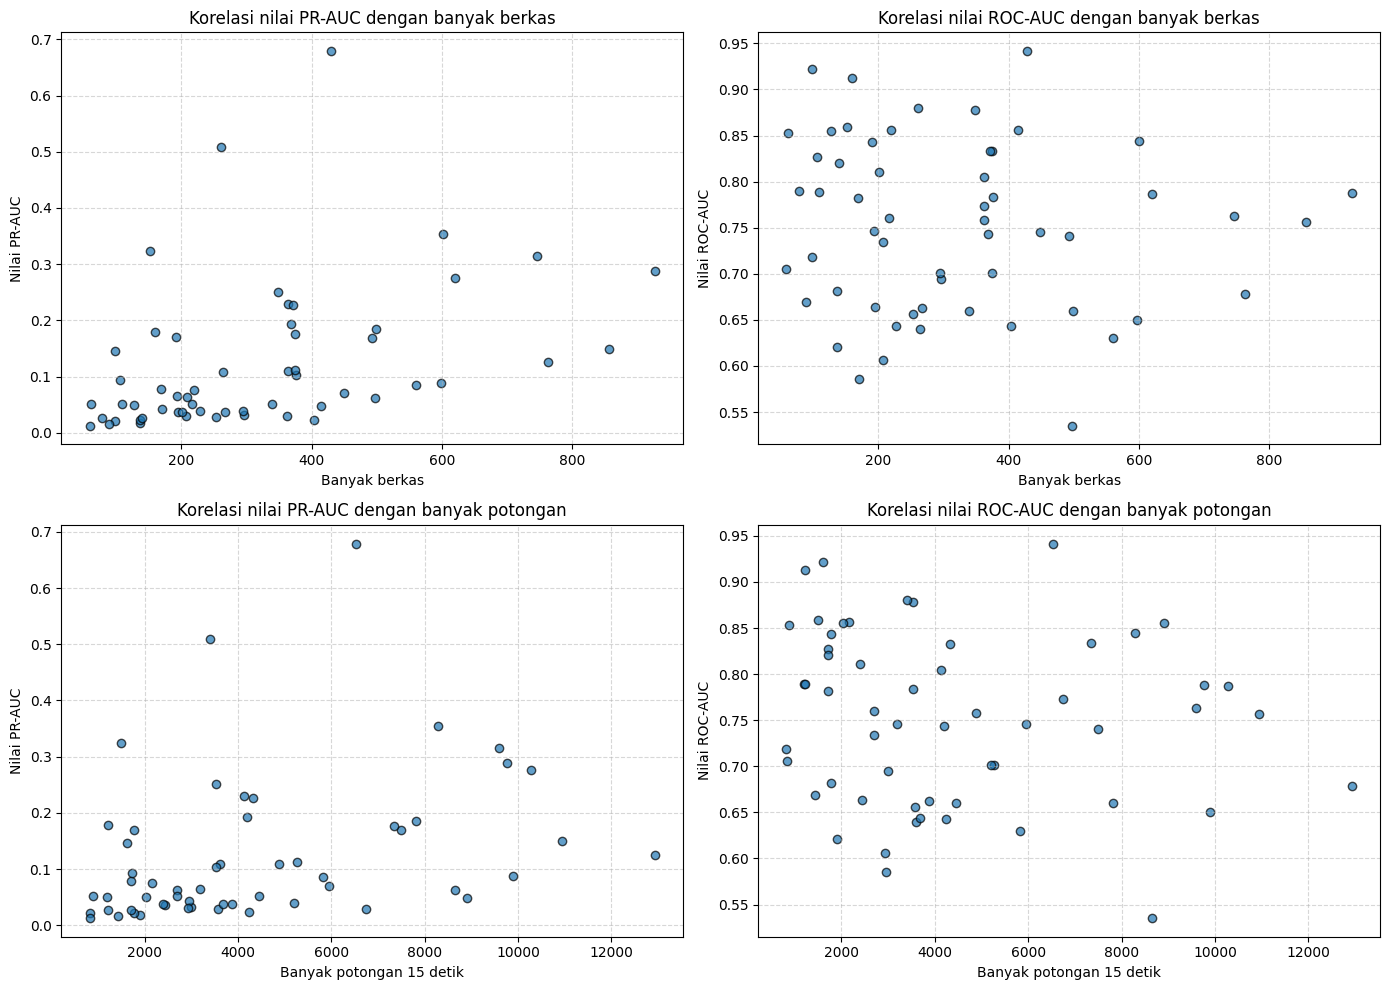

In [16]:
(
    cnn_result_df,
    cnn_merged,
    cnn_pr_auc_files_corr,
    cnn_roc_auc_files_corr,
    cnn_pr_auc_chunks_corr,
    cnn_roc_auc_chunks_corr,
) = calculate_correlations(
    "../prep/autotagging_moodtheme-train_clean.csv",
    "./mlflow_pgdump/cnn_test_9f3cb9_history.csv",
)
print(cnn_result_df)
plot_correlations(
    merged=cnn_merged,
    pr_auc_files_corr=cnn_pr_auc_files_corr,
    roc_auc_files_corr=cnn_roc_auc_files_corr,
    pr_auc_chunks_corr=cnn_pr_auc_files_corr,
    roc_auc_chunks_corr=cnn_roc_auc_chunks_corr,
)

In [17]:
print(cnn_merged)

              files_count   dur_sum  chunks_count    pr_auc   roc_auc
label                                                                
action                296   45005.4          3000  0.032234  0.694500
adventure             264   54096.0          3606  0.108938  0.639852
advertising           363   61884.1          4125  0.229614  0.804738
background            404   63682.6          4245  0.023355  0.642887
ballad                193   47930.5          3195  0.064547  0.746114
calm                  267   58226.3          3881  0.037275  0.662670
children              152   22548.0          1503  0.324197  0.858791
christmas             368   62989.9          4199  0.192688  0.743431
commercial            191   26577.6          1771  0.169779  0.843081
cool                  170   44302.3          2953  0.042363  0.585610
corporate             349   53056.4          3537  0.250537  0.878044
dark                  620  154053.1         10270  0.275770  0.786851
deep                

   pr_auc_files_corr  roc_auc_files_corr  pr_auc_chunks_corr  \
0           0.394279           -0.062149            0.341978   

   roc_auc_chunks_corr  
0             -0.04945  


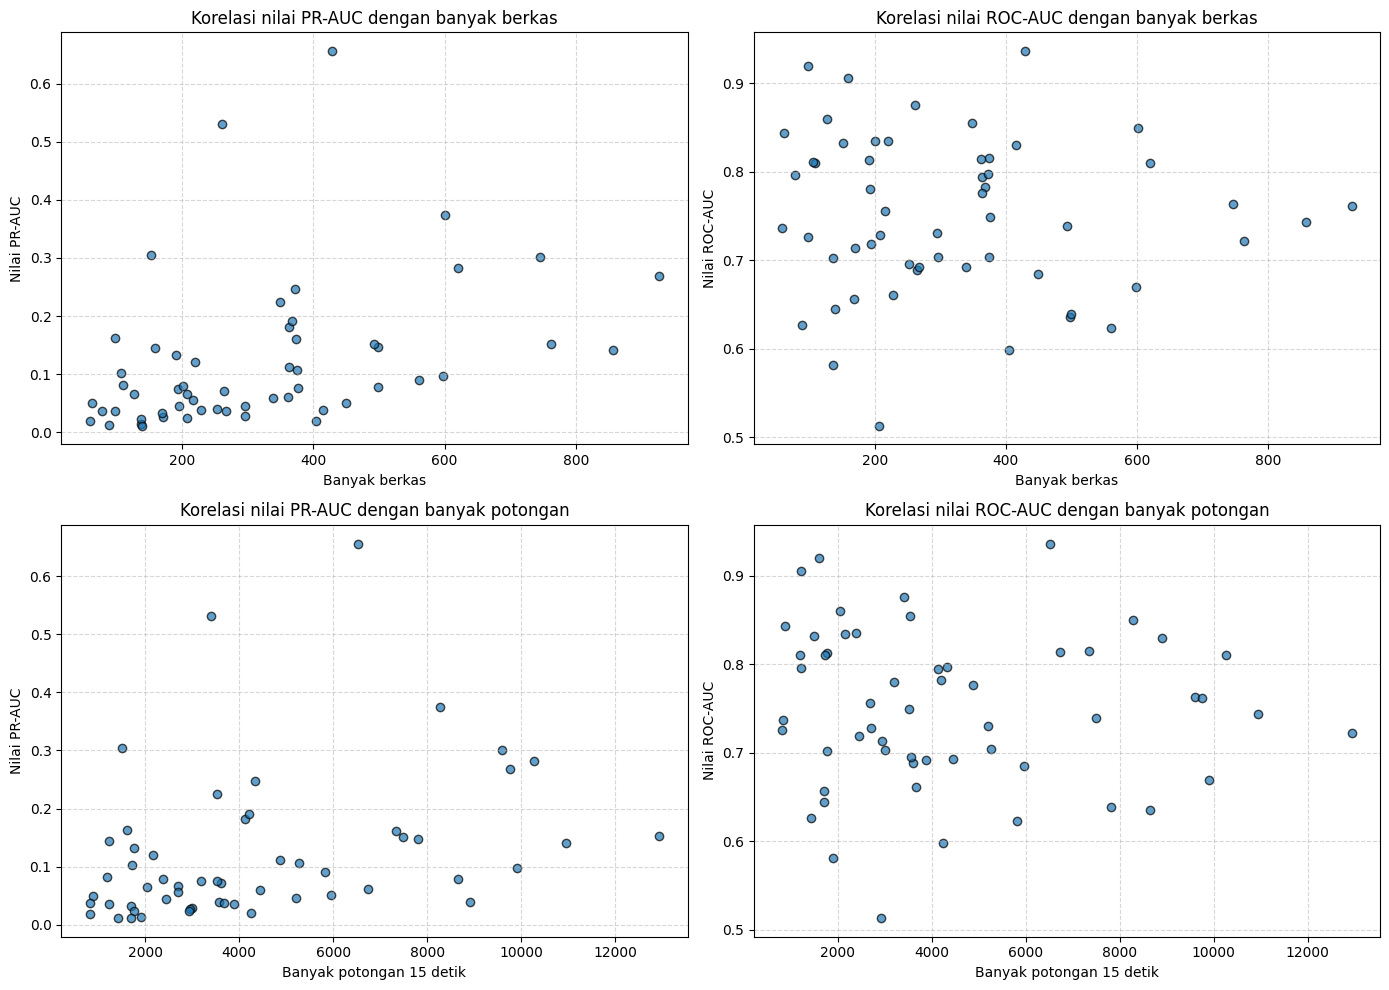

In [18]:
(
    gru_result_df,
    gru_merged,
    gru_pr_auc_files_corr,
    gru_roc_auc_files_corr,
    gru_pr_auc_chunks_corr,
    gru_roc_auc_chunks_corr,
) = calculate_correlations(
    "../prep/autotagging_moodtheme-train_clean.csv",
    "./mlflow_pgdump/gru_test_d68649_history.csv",
)
print(gru_result_df)
plot_correlations(
    merged=gru_merged,
    pr_auc_files_corr=gru_pr_auc_files_corr,
    roc_auc_files_corr=gru_roc_auc_files_corr,
    pr_auc_chunks_corr=gru_pr_auc_files_corr,
    roc_auc_chunks_corr=gru_roc_auc_chunks_corr,
)

   pr_auc_files_corr  roc_auc_files_corr  pr_auc_chunks_corr  \
0           0.368482           -0.076486            0.316647   

   roc_auc_chunks_corr  
0            -0.094658  


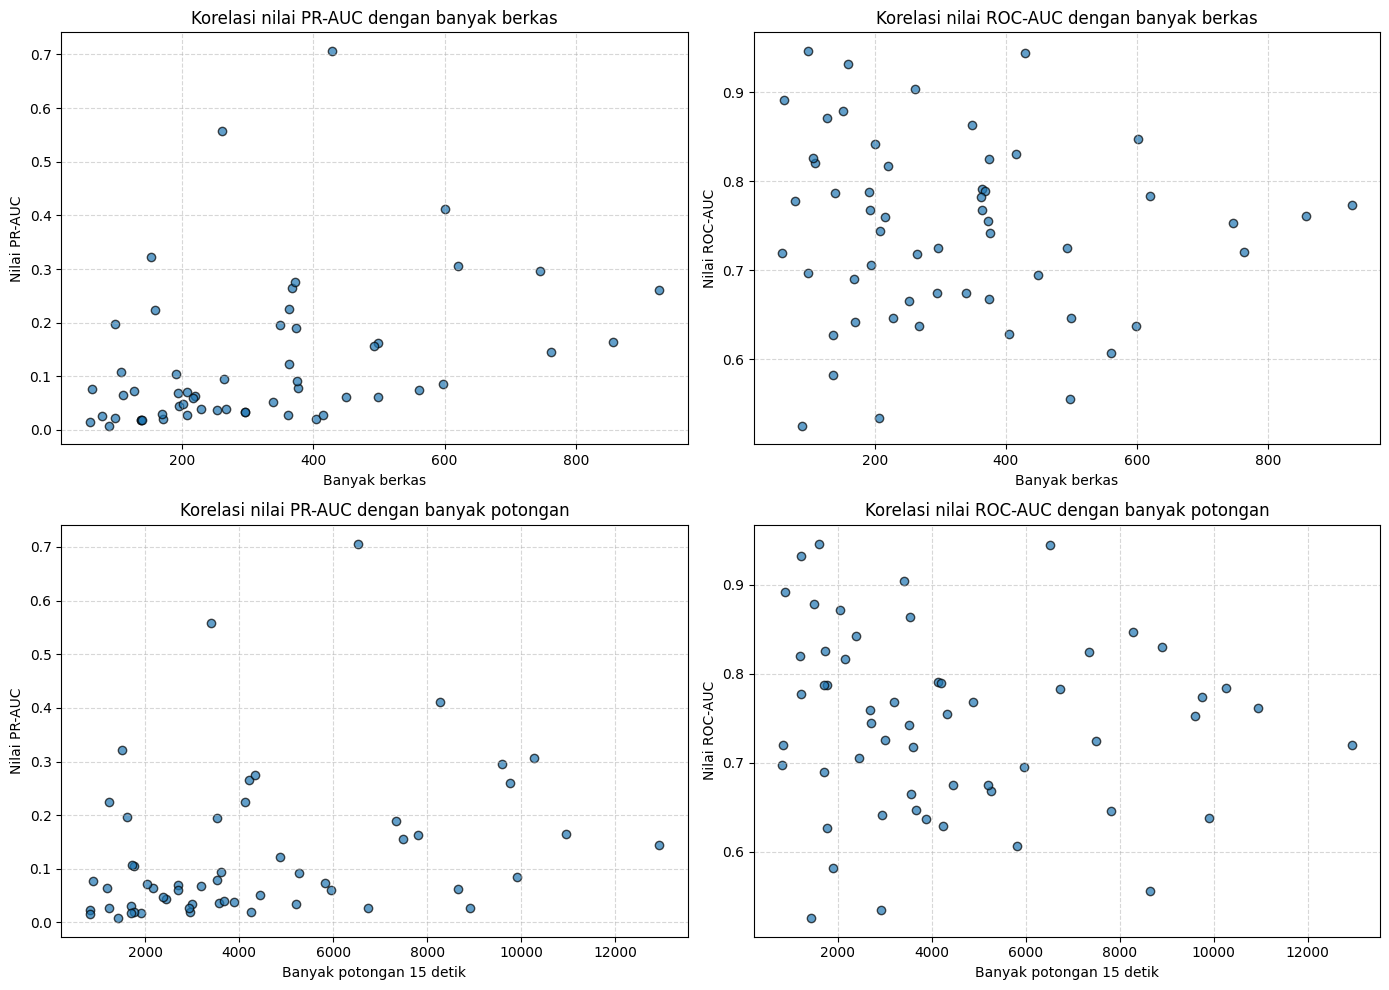

In [19]:
(
    attn_result_df,
    attn_merged,
    attn_pr_auc_files_corr,
    attn_roc_auc_files_corr,
    attn_pr_auc_chunks_corr,
    attn_roc_auc_chunks_corr,
) = calculate_correlations(
    "../prep/autotagging_moodtheme-train_clean.csv",
    "./mlflow_pgdump/attn_test_a98891_history.csv",
)
print(attn_result_df)
plot_correlations(
    merged=attn_merged,
    pr_auc_files_corr=attn_pr_auc_files_corr,
    roc_auc_files_corr=attn_roc_auc_files_corr,
    pr_auc_chunks_corr=attn_pr_auc_files_corr,
    roc_auc_chunks_corr=attn_roc_auc_chunks_corr,
)

# Normality, ANOVA, Kruskal-Wallis 

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from itertools import combinations


def extract_scores(csv_path):
    """Helper to extract PR-AUC and ROC-AUC series from a CSV."""
    df = pd.read_csv(csv_path)
    df["value"] = pd.to_numeric(df["value"], errors="coerce")

    pr_mask = df["key"].str.startswith("test_pr_auc_")
    df_pr = df[pr_mask].copy()
    df_pr["label"] = df_pr["key"].apply(lambda x: x.split("---")[-1])
    pr_scores = df_pr.groupby("label")["value"].mean()

    roc_mask = df["key"].str.startswith("test_roc_auc_")
    df_roc = df[roc_mask].copy()
    df_roc["label"] = df_roc["key"].apply(lambda x: x.split("---")[-1])
    roc_scores = df_roc.groupby("label")["value"].mean()

    return pr_scores, roc_scores


def compare_model_distributions(cnn_csv, gru_csv, attn_csv):
    # 1. Extract data for all 3 models
    pr1, roc1 = extract_scores(cnn_csv)
    pr2, roc2 = extract_scores(gru_csv)
    pr3, roc3 = extract_scores(attn_csv)

    # Align data by label to ensure comparison for the exact same 56 labels
    # and drop any labels that might be missing in one of the files
    df_pr = pd.concat(
        [pr1, pr2, pr3], axis=1, keys=["CNN", "CNN+GRU", "CNN+ATTN"]
    ).dropna()
    df_roc = pd.concat(
        [roc1, roc2, roc3], axis=1, keys=["CNN", "CNN+GRU", "CNN+ATTN"]
    ).dropna()

    # 1. Plot distributions
    fig, axs = plt.subplots(3, 2, figsize=(14, 12))
    fig.suptitle("Distribution of PR-AUC and ROC-AUC scores per model")

    models = ["CNN", "CNN+GRU", "CNN+ATTN"]
    colors = ["skyblue", "salmon", "green"]

    for i, model in enumerate(models):
        # PR-AUC plots (left column)
        sns.histplot(df_pr[model], kde=True, ax=axs[i, 0], color=colors[i], bins=20)  # type: ignore
        axs[i, 0].set_title(f"{model} - PR-AUC")
        axs[i, 0].set_xlabel("Score")
        axs[i, 0].set_ylabel("Frequency")

        # ROC-AUC plots (right column)
        sns.histplot(df_roc[model], kde=True, ax=axs[i, 1], color=colors[i], bins=20)  # type: ignore
        axs[i, 1].set_title(f"{model} - ROC-AUC")
        axs[i, 1].set_xlabel("Score")
        axs[i, 1].set_ylabel("Frequency")

    plt.tight_layout()
    plt.show()

    # 2. Shapiro-Wilk normality test
    print("SHAPIRO-WILK NORMALITY TEST")
    print(
        "Null Hypothesis: The data is normally distributed (p > 0.05 implies normal).\n"
    )

    for model in models:
        stat_pr, p_pr = stats.shapiro(df_pr[model])
        stat_roc, p_roc = stats.shapiro(df_roc[model])
        print(
            f"{model} PR-AUC:  W={stat_pr:.4f}, p={p_pr:.4e} -> {'Normal' if p_pr > 0.05 else 'NOT Normal'}"
        )
        print(
            f"{model} ROC-AUC: W={stat_roc:.4f}, p={p_roc:.4e} -> {'Normal' if p_roc > 0.05 else 'NOT Normal'}"
        )

    # 3. One-Way ANOVA test
    print("\nONE-WAY ANOVA TEST")

    f_stat_pr, p_anova_pr = stats.f_oneway(
        df_pr["CNN"], df_pr["CNN+GRU"], df_pr["CNN+ATTN"]
    )
    f_stat_roc, p_anova_roc = stats.f_oneway(
        df_roc["CNN"], df_roc["CNN+GRU"], df_roc["CNN+ATTN"]
    )

    print(f"PR-AUC  -> F-statistic: {f_stat_pr:.4f}, p-value: {p_anova_pr:.4f}")
    print(f"ROC-AUC -> F-statistic: {f_stat_roc:.4f}, p-value: {p_anova_roc:.4f}")

    # 4. Kruskal-Wallis H-test
    print("\nKRUSKAL-WALLIS H-TEST")

    h_stat_pr, p_kruskal_pr = stats.kruskal(
        df_pr["CNN"], df_pr["CNN+GRU"], df_pr["CNN+ATTN"]
    )
    h_stat_roc, p_kruskal_roc = stats.kruskal(
        df_roc["CNN"], df_roc["CNN+GRU"], df_roc["CNN+ATTN"]
    )

    print(f"PR-AUC  -> H-statistic: {h_stat_pr:.4f}, p-value: {p_kruskal_pr:.4f}")
    print(f"ROC-AUC -> H-statistic: {h_stat_roc:.4f}, p-value: {p_kruskal_roc:.4f}")

    # 5. Friedman Chi-square test
    print("\nFRIEDMAN CHI-SQUARE TEST")

    c_stat_pr, p_friedman_pr = stats.friedmanchisquare(
        df_pr["CNN"], df_pr["CNN+GRU"], df_pr["CNN+ATTN"]
    )
    c_stat_roc, p_friedman_roc = stats.friedmanchisquare(
        df_roc["CNN"], df_roc["CNN+GRU"], df_roc["CNN+ATTN"]
    )

    print(f"PR-AUC  -> Chi-square: {c_stat_pr:.4f}, p-value: {p_friedman_pr:.4f}")
    print(f"ROC-AUC -> Chi-square: {c_stat_roc:.4f}, p-value: {p_friedman_roc:.4f}")

    # 6. Median scores
    print("\nMEDIAN PER-LABEL SCORES")
    print("PR-AUC medians:")
    print(df_pr.median().to_string())
    print("\nROC-AUC medians:")
    print(df_roc.median().to_string())

    # 7. Average (macro) scores
    print("\nAVERAGE (MACRO) PER-LABEL SCORES")
    print("PR-AUC macros:")
    print(df_pr.mean().to_string())
    print("\nROC-AUC macros:")
    print(df_roc.mean().to_string())

    # 8. Wilcoxson signed-rank test
    print("\nWILCOXON SIGNED-RANK TEST (PAIRWISE)")
    print("Note: Because you are doing 3 comparisons, you should ideally apply the")
    print("Bonferroni correction, making your threshold for significance p < 0.0167.\n")

    # itertools.combinations gets all unique pairs (e.g., A/B, A/C, B/C)
    pairs = list(combinations(models, 2))

    print("PR-AUC Pairwise")
    for m1, m2 in pairs:
        stat, p = stats.wilcoxon(df_pr[m1], df_pr[m2])
        print(f"{m1} vs {m2} -> W={stat:.1f}, p-value={p:.4f}")

    print("\nROC-AUC Pairwise")
    for m1, m2 in pairs:
        stat, p = stats.wilcoxon(df_roc[m1], df_roc[m2])
        print(f"{m1} vs {m2} -> W={stat:.1f}, p-value={p:.4f}")

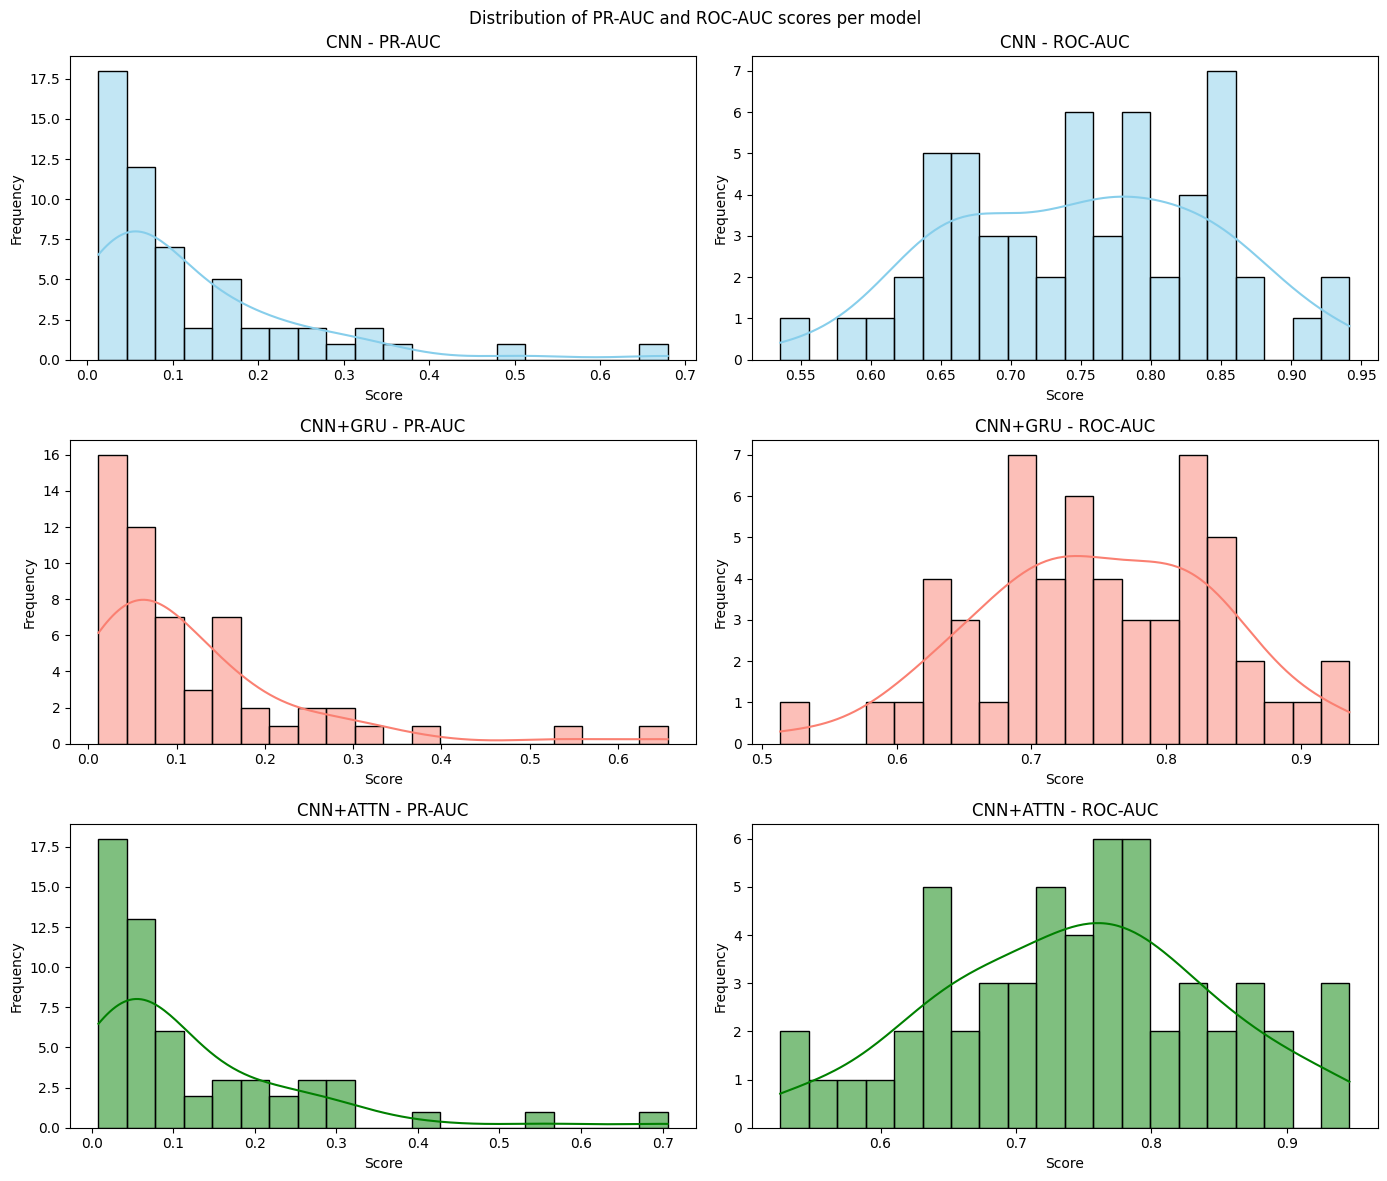

SHAPIRO-WILK NORMALITY TEST
Null Hypothesis: The data is normally distributed (p > 0.05 implies normal).

CNN PR-AUC:  W=0.7576, p=3.0246e-08 -> NOT Normal
CNN ROC-AUC: W=0.9822, p=5.7340e-01 -> Normal
CNN+GRU PR-AUC:  W=0.7511, p=2.2011e-08 -> NOT Normal
CNN+GRU ROC-AUC: W=0.9916, p=9.6327e-01 -> Normal
CNN+ATTN PR-AUC:  W=0.7491, p=1.9924e-08 -> NOT Normal
CNN+ATTN ROC-AUC: W=0.9879, p=8.4364e-01 -> Normal

ONE-WAY ANOVA TEST
PR-AUC  -> F-statistic: 0.0157, p-value: 0.9845
ROC-AUC -> F-statistic: 0.0707, p-value: 0.9318

KRUSKAL-WALLIS H-TEST
PR-AUC  -> H-statistic: 0.0408, p-value: 0.9798
ROC-AUC -> H-statistic: 0.1343, p-value: 0.9351

FRIEDMAN CHI-SQUARE TEST
PR-AUC  -> Chi-square: 0.4643, p-value: 0.7928
ROC-AUC -> Chi-square: 0.4643, p-value: 0.7928

MEDIAN PER-LABEL SCORES
PR-AUC medians:
CNN         0.073189
CNN+GRU     0.077353
CNN+ATTN    0.071154

ROC-AUC medians:
CNN         0.757496
CNN+GRU     0.746312
CNN+ATTN    0.753862

AVERAGE (MACRO) PER-LABEL SCORES
PR-AUC macros:

In [21]:
compare_model_distributions(
    './mlflow_pgdump/cnn_test_9f3cb9_history.csv',
    './mlflow_pgdump/gru_test_d68649_history.csv',
    './mlflow_pgdump/attn_test_a98891_history.csv'
    )

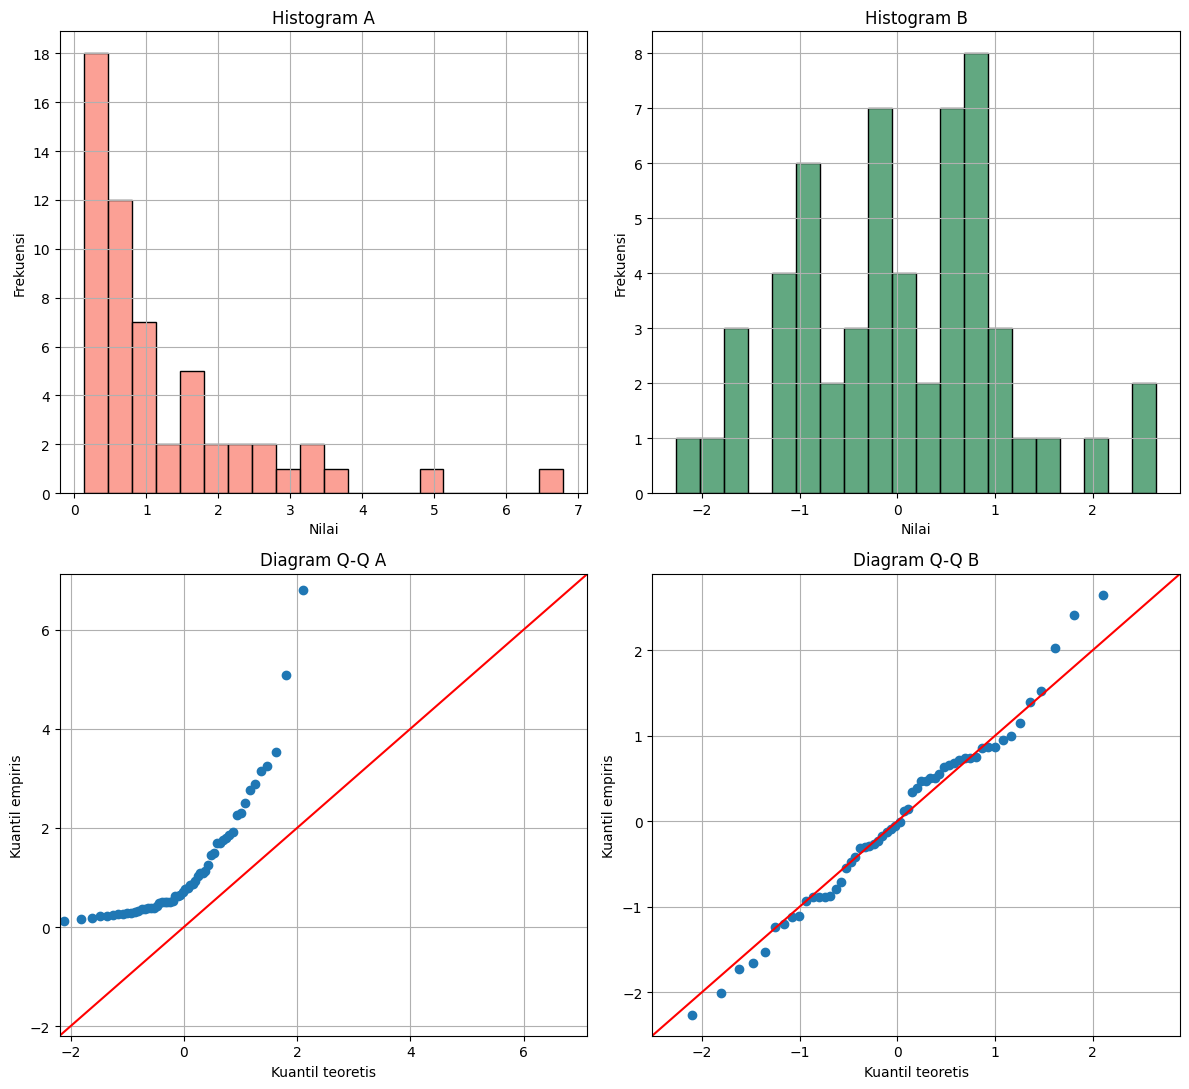

In [76]:
from numpy.random import MT19937
from numpy.random import RandomState, SeedSequence
import statsmodels.api as sm

# import scipy.stats as stats


def visualise_normality(some_csv):
    # This is just for visualisation sake in the final thesis paper
    pr1, roc1 = extract_scores(some_csv)

    rs = RandomState(MT19937(SeedSequence(37)))
    rands = rs.standard_normal(size=56)
    # rands = np.divide(rands, 10)

    _, axs = plt.subplots(2, 2, figsize=(12, 11))

    sns.histplot(pr1 * 10, ax=axs[0, 0], color="salmon", bins=20)
    axs[0, 0].set_title("Histogram A")
    axs[0, 0].set_xlabel("Nilai")
    axs[0, 0].set_ylabel("Frekuensi")
    axs[0, 0].grid()
    # axs[0, 0].set_xticks(np.arange(0.0, 0.8, 0.1))
    axs[0, 0].set_yticks(np.arange(0, 20, 2))

    # stats.probplot(pr1, plot=axs[1, 0])
    # axs[1, 0].set_title("")
    # axs[1, 0].set_xlabel("Kuantil teoretis")
    # axs[1, 0].set_ylabel("Kuantil empiris")
    # axs[1, 0].set_xticks(np.arange(-2, 3, 1))
    # axs[1, 0].set_yticks(np.arange(-2, 3, 1))
    sm.qqplot(pr1 * 10, line="45", ax=axs[1, 0])
    axs[1, 0].set_xlabel("Kuantil teoretis")
    axs[1, 0].set_ylabel("Kuantil empiris")
    axs[1, 0].set_title("Diagram Q-Q A")
    axs[1, 0].grid()
    # axs[1, 0].set_xticks(np.arange(-2, 3, 1))
    # axs[1, 0].set_yticks(np.arange(-2, 3, 1))

    # sns.histplot(roc1 * 10, ax=axs[0, 1], color="cornflowerblue", bins=20)
    # axs[0, 1].set_title("Contoh 2")
    # axs[0, 1].set_xlabel("Nilai")
    # axs[0, 1].set_ylabel("Frekuensi")
    # axs[0, 1].set_xticks(np.arange(0.4, 1.1, 0.1))

    # stats.probplot(roc1, dist="norm", plot=axs[1, 1], fit=False)
    # axs[1, 1].set_title("")
    # axs[1, 1].set_xlabel("Kuantil teoretis")
    # axs[1, 1].set_ylabel("Kuantil empiris")
    # axs[1, 1].set_xticks(np.arange(-2, 3, 1))
    # axs[1, 1].set_yticks(np.arange(-2, 3, 1))
    # sm.qqplot(roc1 * 10, line="45", ax=axs[1, 1])
    # axs[1, 1].set_title("")
    # axs[1, 1].set_xlabel("Kuantil teoretis")
    # axs[1, 1].set_ylabel("Kuantil empiris")
    # axs[1, 1].set_xticks(np.arange(-2, 3, 1))
    # axs[1, 1].set_yticks(np.arange(-2, 3, 1))

    sns.histplot(rands, ax=axs[0, 1], color="seagreen", bins=20)
    axs[0, 1].set_title("Histogram B")
    axs[0, 1].set_xlabel("Nilai")
    axs[0, 1].set_ylabel("Frekuensi")
    axs[0, 1].grid()
    axs[0, 1].set_xticks(np.arange(-2, 3, 1))

    # stats.probplot(rands, plot=axs[1, 1])
    # axs[1, 1].set_title("")
    # axs[1, 1].set_xlabel("Kuantil teoretis")
    # axs[1, 1].set_ylabel("Kuantil empiris")
    # axs[1, 1].set_xticks(np.arange(-2, 3, 1))
    # axs[1, 1].set_yticks(np.arange(-2, 3, 1))
    sm.qqplot(rands, line="45", ax=axs[1, 1])
    axs[1, 1].set_xlabel("Kuantil teoretis")
    axs[1, 1].set_ylabel("Kuantil empiris")
    axs[1, 1].set_title("Diagram Q-Q B")
    axs[1, 1].grid()
    # axs[1, 1].set_xticks(np.arange(-2, 3, 1))
    # axs[1, 1].set_yticks(np.arange(-2, 3, 1))

    plt.tight_layout()
    plt.show()


visualise_normality("./mlflow_pgdump/cnn_test_9f3cb9_history.csv")